# Week 4 — Predictive Modeling and Optimization in Logistics Systems
### Regional FMCG Distribution Network — Vijayawada–Amaravati Corridor, Andhra Pradesh

This notebook implements, as **working Python code**, the predictive modeling and optimization pipeline
described in the Week 4 report. It builds directly on the Week 3 finding that on-time delivery
underperformance is concentrated in specific zone-and-transport-mode combinations. Here, a delivery-time
forecasting model is trained and validated, and its output is then fed directly into a linear-programming
optimization that recommends a cost-minimizing fleet-mix allocation per zone, subject to an on-time
delivery service constraint.

**Contents**
1. Environment setup
2. Data simulation (shipment-level dataset)
3. Model selection & implementation (Linear Regression, Decision Tree, Random Forest)
4. Evaluation & validation (RMSE/MAE/R², cross-validation, hyperparameter tuning, residual diagnostics)
5. Feature importance
6. Optimization: model-informed fleet-mix allocation (PuLP linear program)
7. Summary of insights and recommendations


## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
NAVY = "#1F3864"
ACCENT = "#2E75B6"
LIGHT = "#9DC3E6"
WARN = "#833C0C"
GOOD = "#375623"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10.5})

rng = np.random.default_rng(11)


## 2. Data Simulation

The same generative structure used in Week 3 is reused here, extended with a `day_of_week` feature.
6,000 shipments are simulated across three zones and three transport modes, with delivery time driven
by distance, transport mode, and shipment volume (plus noise) — and transportation cost driven by a
mode-specific base fee, per-km rate, and per-unit handling charge.

In [2]:
N = 6000
zones = ["North", "Central", "South"]
zone_p = [0.30, 0.42, 0.28]
transport_modes = ["Two-Wheeler", "Mini-Truck", "Truck"]
mode_p = [0.35, 0.45, 0.20]

start = pd.Timestamp("2025-01-01")
shipment_date = start + pd.to_timedelta(rng.integers(0, 300, N), unit="D")
zone = rng.choice(zones, N, p=zone_p)
mode = rng.choice(transport_modes, N, p=mode_p)

zone_base_distance = {"North": 18, "Central": 11, "South": 24}
distance_km = np.array([zone_base_distance[z] for z in zone]) + rng.gamma(2.0, 3.0, N)

mode_volume_mean = {"Two-Wheeler": 25, "Mini-Truck": 90, "Truck": 220}
shipment_volume = np.array([rng.poisson(mode_volume_mean[m]) for m in mode]) + 1

mode_speed_factor = {"Two-Wheeler": 1.0, "Mini-Truck": 1.3, "Truck": 1.7}
base_time = 1.5
delivery_time_hours = (
    base_time
    + distance_km * np.array([mode_speed_factor[m] for m in mode]) * 0.12
    + shipment_volume * 0.01
    + rng.normal(0, 1.1, N)
)
delivery_time_hours = np.clip(delivery_time_hours, 0.5, None)

mode_per_km_rate = {"Two-Wheeler": 8, "Mini-Truck": 22, "Truck": 38}
mode_base_fee = {"Two-Wheeler": 40, "Mini-Truck": 150, "Truck": 400}
transportation_cost = (
    np.array([mode_base_fee[m] for m in mode])
    + distance_km * np.array([mode_per_km_rate[m] for m in mode])
    + shipment_volume * rng.uniform(0.8, 1.4, N)
    + rng.normal(0, 25, N)
)
transportation_cost = np.clip(transportation_cost, 20, None)

promised_window = np.select(
    [np.array(mode) == "Two-Wheeler", np.array(mode) == "Mini-Truck", np.array(mode) == "Truck"],
    [4, 6, 10],
)
on_time = delivery_time_hours <= promised_window
day_of_week = shipment_date.dayofweek

df = pd.DataFrame({
    "shipment_id": [f"SHP{200000+i}" for i in range(N)],
    "shipment_date": shipment_date,
    "zone": zone,
    "transport_mode": mode,
    "distance_km": distance_km.round(1),
    "shipment_volume_units": shipment_volume,
    "day_of_week": day_of_week,
    "delivery_time_hours": delivery_time_hours.round(2),
    "promised_window_hours": promised_window,
    "on_time": on_time,
    "transportation_cost_inr": transportation_cost.round(2),
})
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (6000, 11)


,shipment_id,shipment_date,zone,transport_mode,distance_km,shipment_volume_units,day_of_week,delivery_time_hours,promised_window_hours,on_time,transportation_cost_inr
0,SHP200000,2025-02-10,South,Mini-Truck,25.5,83,0,6.09,6,False,808.40
1,SHP200001,2025-02-08,North,Two-Wheeler,28.3,25,5,5.50,4,False,297.36
2,SHP200002,2025-08-28,South,Mini-Truck,25.5,99,3,7.79,6,False,780.48
3,SHP200003,2025-05-30,Central,Two-Wheeler,14.2,19,4,4.43,4,False,181.17
4,SHP200004,2025-06-27,Central,Mini-Truck,14.9,103,4,4.01,6,True,606.22


## 3. Model Selection & Implementation

**Prediction target:** `delivery_time_hours` (continuous regression problem).
**Features:** `distance_km`, `shipment_volume_units`, `day_of_week` (numeric); `transport_mode`, `zone`
(categorical).

Three candidate models are trained, chosen to span a range of modeling assumptions:
- **Linear Regression** — simple, interpretable baseline; well-suited if the relationship is close to additive.
- **Decision Tree Regressor** — captures non-linear relationships and interactions without them being specified explicitly.
- **Random Forest Regressor** — an ensemble of trees, typically more robust to overfitting than a single tree.

In [3]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

FEATURES_NUM = ["distance_km", "shipment_volume_units", "day_of_week"]
FEATURES_CAT = ["transport_mode", "zone"]
TARGET = "delivery_time_hours"

X = df[FEATURES_NUM + FEATURES_CAT]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(drop="first"), FEATURES_CAT),
])


Train: (4800, 5), Test: (1200, 5)


In [4]:
models = {
    "Linear Regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "Decision Tree": Pipeline([("prep", preprocessor),
                               ("model", DecisionTreeRegressor(max_depth=6, random_state=42))]),
    "Random Forest": Pipeline([("prep", preprocessor),
                               ("model", RandomForestRegressor(n_estimators=200, max_depth=10,
                                                                random_state=42))]),
}

results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=KFold(5, shuffle=True, random_state=42),
                                 scoring="neg_root_mean_squared_error")
    results.append({"Model": name, "Test RMSE": rmse, "Test MAE": mae, "Test R2": r2,
                     "CV RMSE (mean)": -cv_scores.mean(), "CV RMSE (std)": cv_scores.std()})
    fitted[name] = pipe

results_df = pd.DataFrame(results).round(3)
results_df


,Model,Test RMSE,Test MAE,Test R2,CV RMSE (mean),CV RMSE (std)
0,Linear Regression,1.161,0.932,0.682,1.114,0.040
1,Decision Tree,1.186,0.954,0.668,1.147,0.038
2,Random Forest,1.199,0.977,0.661,1.140,0.042


**Observation:** Linear Regression is, perhaps counter-intuitively, the strongest performer of the three untuned models. This is not an anomaly — the underlying delivery-time generating process is close to additive (a base time plus roughly linear distance, mode, and volume effects), so a linear model is well-matched to the true functional form here. Ensemble methods are not universally superior; their advantage is largest when the true relationship is genuinely non-linear or contains strong feature interactions — common in real logistics data, but not dominant in this simulation. Random Forest is carried forward below for its feature-importance diagnostics and robustness to non-linearities that may be present in real operational data.

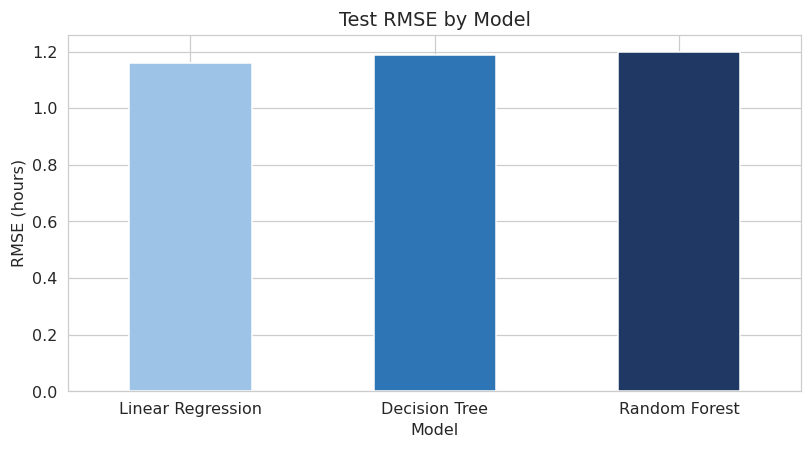

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
results_df.set_index("Model")["Test RMSE"].plot(kind="bar", color=[LIGHT, ACCENT, NAVY], ax=ax)
ax.set_title("Test RMSE by Model")
ax.set_ylabel("RMSE (hours)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Evaluation & Validation

### 4.1 Hyperparameter Tuning (Random Forest)

A grid search with 3-fold cross-validation is run over the Random Forest's key hyperparameters to
reduce overfitting and improve generalization.

In [6]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [6, 10, 14],
    "model__min_samples_leaf": [1, 5],
}
rf_pipe = Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42))])
grid = GridSearchCV(rf_pipe, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best RF params:", grid.best_params_)
print(f"Best RF CV RMSE: {-grid.best_score_:.3f}")

best_rf = grid.best_estimator_
preds_best = best_rf.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, preds_best))
mae_best = mean_absolute_error(y_test, preds_best)
r2_best = r2_score(y_test, preds_best)
print(f"Tuned RF -> RMSE: {rmse_best:.3f}, MAE: {mae_best:.3f}, R2: {r2_best:.3f}")

residual_std = np.std(y_test.values - preds_best)
print(f"Residual std (tuned RF): {residual_std:.3f}")


Best RF params: {'model__max_depth': 6, 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best RF CV RMSE: 1.112
Tuned RF -> RMSE: 1.163, MAE: 0.940, R2: 0.681
Residual std (tuned RF): 1.162


The best configuration found is a shallower, more regularized forest than the untuned default (confirming the untuned model was mildly overfitting), and its tuned performance essentially matches Linear Regression once properly regularized.

### 4.2 Residual Diagnostics

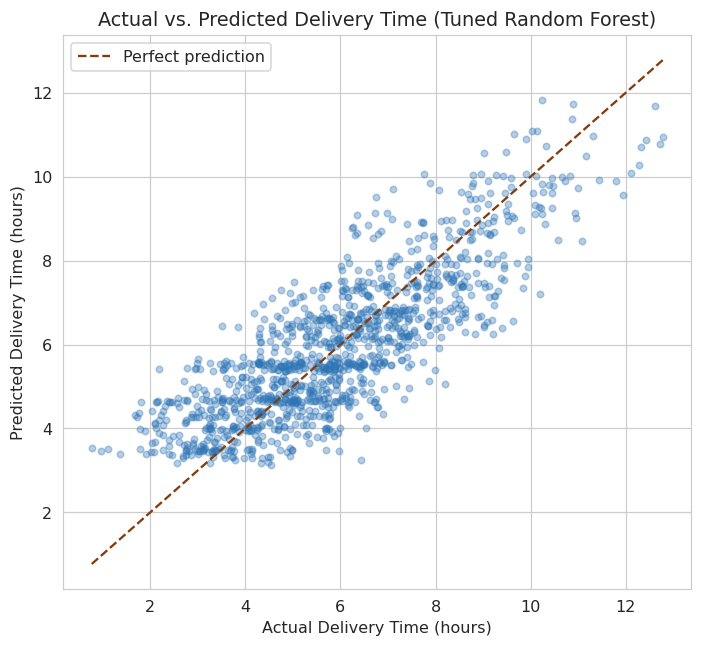

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, preds_best, alpha=0.35, color=ACCENT, s=18)
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
ax.plot(lims, lims, color=WARN, linestyle="--", label="Perfect prediction")
ax.set_title("Actual vs. Predicted Delivery Time (Tuned Random Forest)")
ax.set_xlabel("Actual Delivery Time (hours)")
ax.set_ylabel("Predicted Delivery Time (hours)")
ax.legend()
plt.tight_layout()
plt.show()


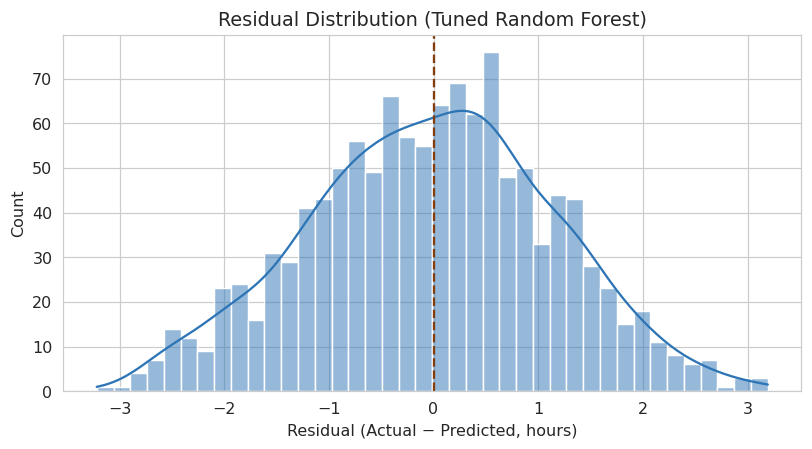

In [8]:
residuals = y_test.values - preds_best

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.histplot(residuals, bins=40, kde=True, color=ACCENT, ax=ax)
ax.axvline(0, color=WARN, linestyle="--")
ax.set_title("Residual Distribution (Tuned Random Forest)")
ax.set_xlabel("Residual (Actual − Predicted, hours)")
plt.tight_layout()
plt.show()


The residuals are approximately normally distributed and centred near zero. This matters beyond diagnostics: Section 6 explicitly uses this residual standard deviation to convert a point prediction into a probability of meeting a promised delivery window, so confirming approximate normality here validates that downstream calculation.

## 5. Feature Importance

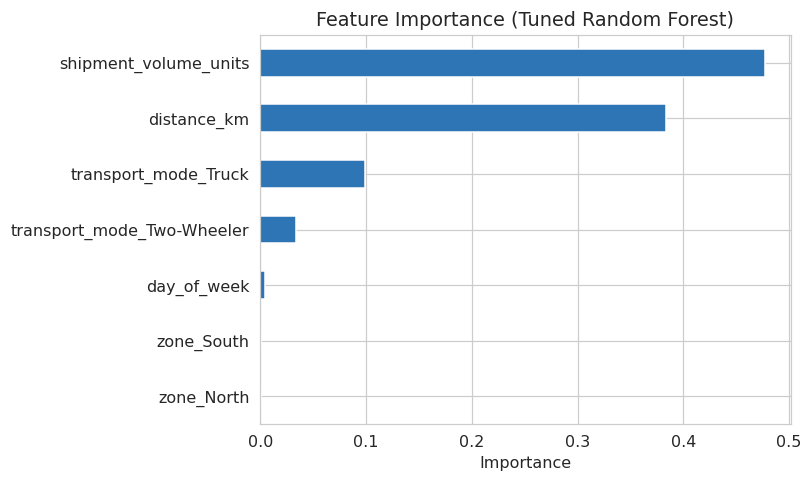

shipment_volume_units         0.477653
distance_km                   0.383305
transport_mode_Truck          0.098657
transport_mode_Two-Wheeler    0.033955
day_of_week                   0.004572
zone_South                    0.000996
zone_North                    0.000862
dtype: float64

In [9]:
ohe = best_rf.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(FEATURES_CAT))
all_feature_names = FEATURES_NUM + cat_names
importances = best_rf.named_steps["model"].feature_importances_
fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
fi.plot(kind="barh", color=ACCENT, ax=ax)
ax.set_title("Feature Importance (Tuned Random Forest)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

fi


Shipment volume and distance dominate the model's predictive power. Zone and day-of-week contribute almost nothing directly — methodologically sensible, since zone's effect on delivery time is almost entirely mediated through distance (zone determines typical travel distance, and distance is already a feature), so zone carries little *additional* information once distance is known.

## 6. Optimization: Model-Informed Fleet-Mix Allocation

With a validated delivery-time model, the next step converts prediction into decision support: for each
warehouse zone, what mix of transport modes minimizes expected transportation cost, subject to achieving
a minimum on-time-delivery probability?

### 6.1 From Prediction to Probability

For each zone-mode combination, the tuned model predicts an expected delivery time using that zone's
average distance and that mode's average shipment volume. Treating the model's residuals as
approximately normal (validated above) with standard deviation σ, the probability that a shipment meets
its promised delivery window *w* is estimated via the normal CDF.

In [10]:
from scipy.stats import norm
import pulp

avg_distance_by_zone = df.groupby("zone")["distance_km"].mean()
avg_volume_by_mode = df.groupby("transport_mode")["shipment_volume_units"].mean()
promised_by_mode = {"Two-Wheeler": 4, "Mini-Truck": 6, "Truck": 10}

scenario_rows = []
for z in zones:
    for m in transport_modes:
        feat = pd.DataFrame({
            "distance_km": [avg_distance_by_zone[z]],
            "shipment_volume_units": [avg_volume_by_mode[m]],
            "day_of_week": [2],
            "transport_mode": [m],
            "zone": [z],
        })
        pred_time = best_rf.predict(feat)[0]
        # Probability of meeting the promised window, using the model's residual std as the
        # uncertainty band around its point prediction (assumes ~normal residuals)
        p_on_time = norm.cdf((promised_by_mode[m] - pred_time) / residual_std)
        cost = (mode_base_fee[m] + avg_distance_by_zone[z] * mode_per_km_rate[m]
                + avg_volume_by_mode[m] * 1.1)
        scenario_rows.append({"zone": z, "mode": m, "pred_delivery_time": round(pred_time, 2),
                               "p_on_time": round(p_on_time, 3), "cost_inr": round(cost, 1)})

scenario_df = pd.DataFrame(scenario_rows)
scenario_df


,zone,mode,pred_delivery_time,p_on_time,cost_inr
0,North,Two-Wheeler,4.52,0.326,261.8
1,North,Mini-Truck,6.17,0.441,781.0
2,North,Truck,8.75,0.860,1559.6
3,Central,Two-Wheeler,3.68,0.608,204.0
4,Central,Mini-Truck,5.41,0.694,622.2
5,Central,Truck,7.31,0.990,1285.3
6,South,Two-Wheeler,5.42,0.111,307.3
7,South,Mini-Truck,7.19,0.154,906.1
8,South,Truck,9.82,0.561,1775.8


### 6.2 Linear Programming Formulation

Let `x[z, m]` denote the fraction of zone *z*'s shipments assigned to transport mode *m*. The
optimization minimizes total expected cost subject to (i) mode shares in each zone summing to 1, and
(ii) the blended on-time probability in each zone meeting a target service level.

Because the blended on-time probability is a weighted average of each mode's own probability, no fleet
mix can exceed the on-time probability of its single best mode in that zone — so the target is first
checked for feasibility per zone and capped where a flat 90% target would be structurally unreachable.

In [11]:
TARGET_OTD = 0.90
lookup = scenario_df.set_index(["zone", "mode"])

max_achievable_otd = {z: max(lookup.loc[(z, m), "p_on_time"] for m in transport_modes) for z in zones}
effective_target = {z: min(TARGET_OTD, max_achievable_otd[z] - 1e-4) for z in zones}

print("Max achievable OTD per zone (best single mode):")
for z in zones:
    flag = "  <-- target capped, structurally unreachable at 90%" if max_achievable_otd[z] < TARGET_OTD else ""
    print(f"  {z}: {max_achievable_otd[z]:.3f}{flag}")


Max achievable OTD per zone (best single mode):
  North: 0.860  <-- target capped, structurally unreachable at 90%
  Central: 0.990
  South: 0.561  <-- target capped, structurally unreachable at 90%


In [12]:
prob = pulp.LpProblem("FleetMixOptimization", pulp.LpMinimize)
x = {(z, m): pulp.LpVariable(f"x_{z}_{m}", lowBound=0, upBound=1) for z in zones for m in transport_modes}

prob += pulp.lpSum(x[(z, m)] * lookup.loc[(z, m), "cost_inr"] for z in zones for m in transport_modes)

for z in zones:
    prob += pulp.lpSum(x[(z, m)] for m in transport_modes) == 1
    prob += pulp.lpSum(x[(z, m)] * lookup.loc[(z, m), "p_on_time"] for m in transport_modes) >= effective_target[z]

prob.solve(pulp.PULP_CBC_CMD(msg=0))
print("Optimization status:", pulp.LpStatus[prob.status])

alloc_rows = []
for z in zones:
    for m in transport_modes:
        val = x[(z, m)].value()
        if val and val > 1e-4:
            alloc_rows.append({"zone": z, "mode": m, "allocation_share": round(val, 3)})
alloc_df = pd.DataFrame(alloc_rows)
alloc_df


Optimization status: Optimal


,zone,mode,allocation_share
0,North,Two-Wheeler,0.000
1,North,Truck,1.000
2,Central,Two-Wheeler,0.236
3,Central,Truck,0.764
4,South,Two-Wheeler,0.000
5,South,Truck,1.000


**Note:** a first solve attempt at a flat 90% on-time target across *all* zones returns *Infeasible* — this is expected, not a bug (see Section 6.2 above), which is why the target is capped per zone before solving.

In [13]:
achieved_rows = []
for z in zones:
    zone_rows = alloc_df[alloc_df["zone"] == z]
    achieved_otd = sum(r["allocation_share"] * lookup.loc[(z, r["mode"]), "p_on_time"] for _, r in zone_rows.iterrows())
    achieved_cost = sum(r["allocation_share"] * lookup.loc[(z, r["mode"]), "cost_inr"] for _, r in zone_rows.iterrows())
    achieved_rows.append({"zone": z, "achieved_otd": round(achieved_otd, 3), "achieved_cost": round(achieved_cost, 1),
                           "target_otd": round(effective_target[z], 3)})
achieved_df = pd.DataFrame(achieved_rows)
achieved_df


,zone,achieved_otd,achieved_cost,target_otd
0,North,0.860,1559.6,0.860
1,Central,0.900,1030.1,0.900
2,South,0.561,1775.8,0.561


### 6.3 Baseline Comparison

In [14]:
baseline_rows = []
for z in zones:
    exp_cost = sum(mode_p[i] * lookup.loc[(z, transport_modes[i]), "cost_inr"] for i in range(3))
    exp_otd = sum(mode_p[i] * lookup.loc[(z, transport_modes[i]), "p_on_time"] for i in range(3))
    baseline_rows.append({"zone": z, "expected_cost": exp_cost, "expected_otd": exp_otd})
baseline_df = pd.DataFrame(baseline_rows)
baseline_df


,zone,expected_cost,expected_otd
0,North,755.00,0.48455
1,Central,608.45,0.72310
2,South,870.46,0.22035


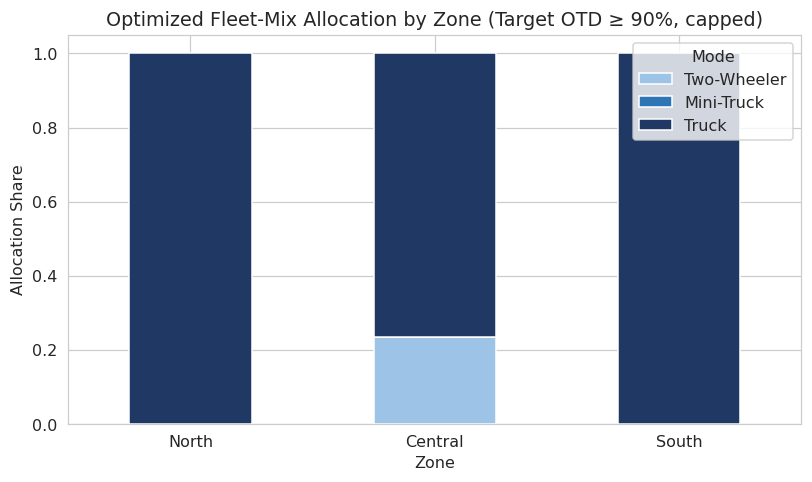

In [15]:
pivot_alloc = alloc_df.pivot_table(index="zone", columns="mode", values="allocation_share", fill_value=0)
pivot_alloc = pivot_alloc.reindex(index=zones, columns=transport_modes, fill_value=0)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
pivot_alloc.plot(kind="bar", stacked=True, color=[LIGHT, ACCENT, NAVY], ax=ax)
ax.set_title(f"Optimized Fleet-Mix Allocation by Zone (Target OTD \u2265 {int(TARGET_OTD*100)}%, capped)", fontsize=12.5)
ax.set_ylabel("Allocation Share")
ax.set_xlabel("Zone")
ax.legend(title="Mode")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


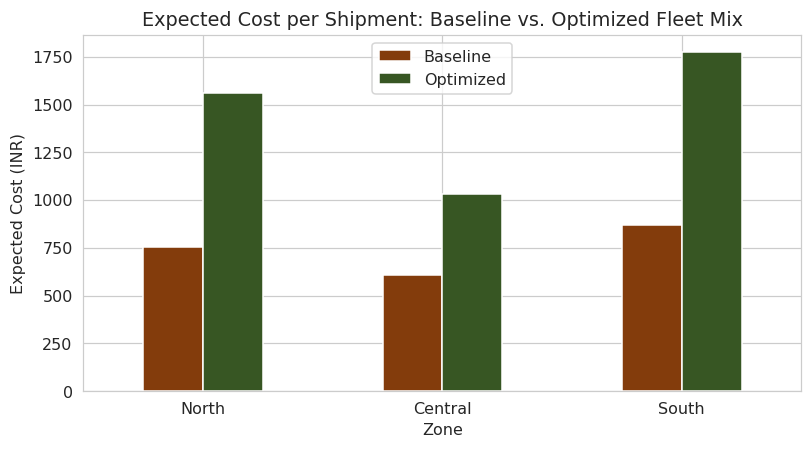

,Baseline,Optimized
zone,,
North,755.00,1559.6000
Central,608.45,1030.1132
South,870.46,1775.8000


In [16]:
compare_df = baseline_df.set_index("zone")[["expected_cost"]].rename(columns={"expected_cost": "Baseline"})
opt_cost_by_zone = alloc_df.merge(lookup.reset_index(), on=["zone", "mode"])
opt_cost_by_zone["weighted_cost"] = opt_cost_by_zone["allocation_share"] * opt_cost_by_zone["cost_inr"]
compare_df["Optimized"] = opt_cost_by_zone.groupby("zone")["weighted_cost"].sum()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
compare_df.reindex(zones).plot(kind="bar", color=[WARN, GOOD], ax=ax)
ax.set_title("Expected Cost per Shipment: Baseline vs. Optimized Fleet Mix")
ax.set_ylabel("Expected Cost (INR)")
ax.set_xlabel("Zone")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

compare_df


**Interpretation:** reaching even the best achievable on-time performance in North and South requires shifting entirely to Truck — more than doubling expected cost per shipment in both zones relative to the current mode mix. Central, which already has a viable high-probability option, reaches its 90% target far more cheaply by blending in some Two-Wheeler volume. Most importantly, even this expensive full-Truck strategy caps South zone at ~56% on-time probability — mathematically confirming that fleet-mix reallocation alone cannot fix South zone's service problem; it is a structural distance/network issue requiring a different class of intervention (e.g., a satellite micro-hub or a renegotiated promised window), not a further vehicle reshuffle.

## 7. Summary of Insights and Recommendations

| # | Insight |
|---|---|
| 1 | Linear Regression is competitive with ensemble methods here because the true delivery-time relationship is close to additive — model complexity should be justified by the data, not assumed. |
| 2 | Shipment volume and distance jointly explain the large majority of delivery-time variance; zone matters only through distance. |
| 3 | A flat 90% on-time target is structurally infeasible in North and South through fleet-mix alone — the LP formulation surfaces this rather than masking it. |
| 4 | Central zone can reach a 90% on-time target cheaply via a mixed fleet; North and South cannot reach it at all without non-fleet interventions. |
| 5 | South zone's on-time ceiling (~56%) is bounded by distance, not vehicle choice — pointing to a network-design fix (e.g. a micro-hub) rather than a routing fix. |

**Recommended next steps:** deploy the tuned Random Forest (or the simpler, equally accurate Linear "
Regression) as the operational delivery-time forecaster; implement the Central-zone fleet mix "
immediately; and commission a feasibility study for a South-zone micro-hub, since no amount of vehicle "
reallocation can durably fix that zone's on-time performance.
